<a href="https://colab.research.google.com/github/ashikamujib21-png/ShadowFox-Sentiment-Analysis/blob/main/Sentiment_Analysis_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Phase 2: DATA LOADING & EXPLORATION**

In [3]:
# DATA LOADING & EXPLORATION
# X (Twitter) Sentiment Analysis Project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import files
uploaded = files.upload()

Saving X data.csv to X data.csv


In [5]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("X data.csv")

print("=" * 50)
print("✅ Dataset Loaded Successfully!")
print("=" * 50)
print(df.shape)
print(df.head())

✅ Dataset Loaded Successfully!
(162980, 2)
                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0
2  what did just say vote for modi  welcome bjp t...       1.0
3  asking his supporters prefix chowkidar their n...       1.0
4  answer who among these the most powerful world...       1.0


In [6]:
# Basic Overview

print("\n📌 SHAPE OF DATASET (rows, columns):")
print(df.shape)

print("\n📌 COLUMN NAMES:")
print(df.columns.tolist())

print("\n📌 FIRST 5 ROWS:")
print(df.head())

print("\n📌 DATA TYPES OF EACH COLUMN:")
print(df.dtypes)

print("\n📌 BASIC STATISTICS:")
print(df.describe(include='all'))


📌 SHAPE OF DATASET (rows, columns):
(162980, 2)

📌 COLUMN NAMES:
['clean_text', 'category']

📌 FIRST 5 ROWS:
                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0
2  what did just say vote for modi  welcome bjp t...       1.0
3  asking his supporters prefix chowkidar their n...       1.0
4  answer who among these the most powerful world...       1.0

📌 DATA TYPES OF EACH COLUMN:
clean_text     object
category      float64
dtype: object

📌 BASIC STATISTICS:
       clean_text       category
count      162976  162973.000000
unique     162975            NaN
top          2019            NaN
freq            2            NaN
mean          NaN       0.225436
std           NaN       0.781279
min           NaN      -1.000000
25%           NaN       0.000000
50%           NaN       0.000000
75%           NaN       1.000000
max           NaN       1.000000


In [7]:
#Check for Missing Values

print("\n📌 MISSING VALUES PER COLUMN:")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent.round(2)
})
print(missing_df[missing_df['Missing Count'] > 0])


📌 MISSING VALUES PER COLUMN:
            Missing Count  Missing %
clean_text              4        0.0
category                7        0.0


In [8]:
# Check for Duplicate Rows

duplicates = df.duplicated().sum()
print(f"\n📌 DUPLICATE ROWS: {duplicates}")



📌 DUPLICATE ROWS: 2


In [9]:
# Explore the Tweet Text Column

TWEET_COLUMN = 'clean_text'

if TWEET_COLUMN in df.columns:
    print(f"\n📌 SAMPLE TWEETS (column: '{TWEET_COLUMN}'):")
    for i, tweet in enumerate(df[TWEET_COLUMN].dropna().head(5)):
        print(f"  [{i+1}] {tweet}")

    # Tweet length distribution
    df['tweet_length'] = df[TWEET_COLUMN].astype(str).apply(len)
    print(f"\n📌 TWEET LENGTH STATS:")
    print(df['tweet_length'].describe())
else:
    print(f"\n⚠️ Column '{TWEET_COLUMN}' not found. Please update TWEET_COLUMN variable.")
    print("Available columns:", df.columns.tolist())



📌 SAMPLE TWEETS (column: 'clean_text'):
  [1] when modi promised “minimum government maximum governance” expected him begin the difficult job reforming the state why does take years get justice state should and not business and should exit psus and temples
  [2] talk all the nonsense and continue all the drama will vote for modi 
  [3] what did just say vote for modi  welcome bjp told you rahul the main campaigner for modi think modi should just relax
  [4] asking his supporters prefix chowkidar their names modi did great service now there confusion what read what not now crustal clear what will crass filthy nonsensical see how most abuses are coming from chowkidars
  [5] answer who among these the most powerful world leader today trump putin modi may 

📌 TWEET LENGTH STATS:
count    162980.000000
mean        124.173512
std          67.925115
min           1.000000
25%          66.000000
50%         114.000000
75%         183.000000
max         274.000000
Name: tweet_length, dtype: fl

In [10]:
# Explore Date Column (if available)

DATE_COLUMN = 'date'

if DATE_COLUMN in df.columns:
    df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN], errors='coerce')
    print(f"\n📌 DATE RANGE:")
    print(f"  From : {df[DATE_COLUMN].min()}")
    print(f"  To   : {df[DATE_COLUMN].max()}")

    # Tweets per month
    df['month'] = df[DATE_COLUMN].dt.to_period('M')
    tweets_per_month = df.groupby('month').size()
    print(f"\n📌 TWEETS PER MONTH:")
    print(tweets_per_month)
else:
    print(f"\n⚠️ Date column '{DATE_COLUMN}' not found. Skipping time-based analysis.")



⚠️ Date column 'date' not found. Skipping time-based analysis.


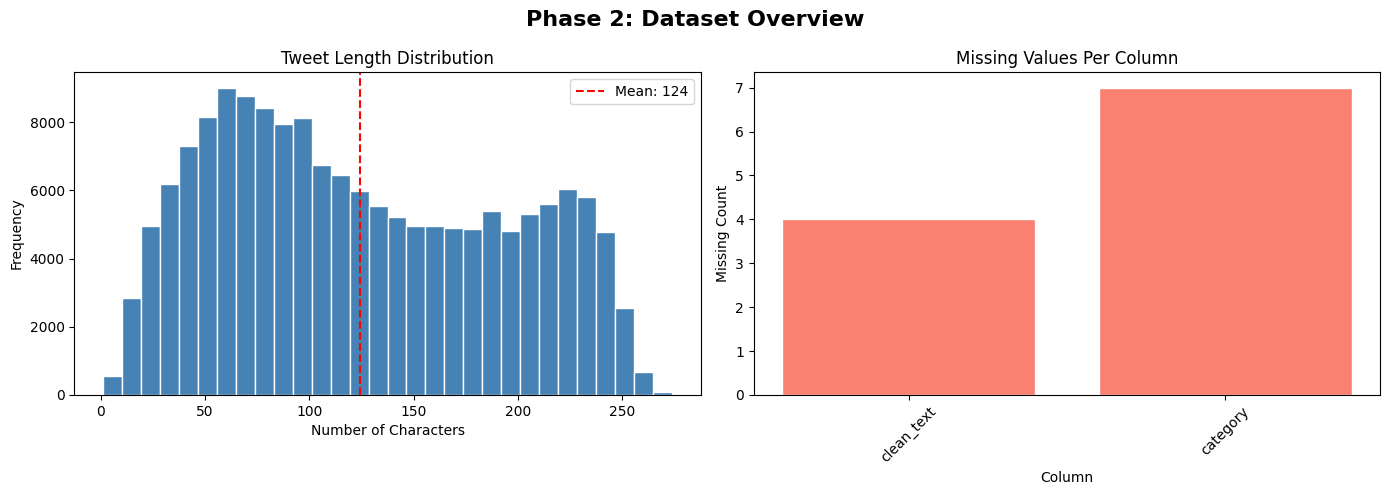


✅ Chart saved as 'phase2_overview.png'


In [11]:
# Visualizations

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phase 2: Dataset Overview', fontsize=16, fontweight='bold')

# Plot 1: Tweet Length Distribution
if 'tweet_length' in df.columns:
    axes[0].hist(df['tweet_length'], bins=30, color='steelblue', edgecolor='white')
    axes[0].set_title('Tweet Length Distribution')
    axes[0].set_xlabel('Number of Characters')
    axes[0].set_ylabel('Frequency')
    axes[0].axvline(df['tweet_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['tweet_length'].mean():.0f}")
    axes[0].legend()

# Plot 2: Tweets Over Time
if DATE_COLUMN in df.columns and 'month' in df.columns:
    tweets_per_month_values = df.groupby('month').size()
    axes[1].plot(tweets_per_month_values.index.astype(str),
                 tweets_per_month_values.values,
                 marker='o', color='teal', linewidth=2)
    axes[1].set_title('Tweets Over Time (Monthly)')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Number of Tweets')
    axes[1].tick_params(axis='x', rotation=45)
else:
    # If no date column, show missing values chart
    missing_counts = df.isnull().sum()
    missing_counts = missing_counts[missing_counts > 0]
    if not missing_counts.empty:
        axes[1].bar(missing_counts.index, missing_counts.values, color='salmon', edgecolor='white')
        axes[1].set_title('Missing Values Per Column')
        axes[1].set_xlabel('Column')
        axes[1].set_ylabel('Missing Count')
        axes[1].tick_params(axis='x', rotation=45)
    else:
        axes[1].text(0.5, 0.5, 'No Missing Values! ✅',
                     ha='center', va='center', fontsize=14, color='green')
        axes[1].set_title('Missing Values Check')

plt.tight_layout()
plt.savefig('phase2_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Chart saved as 'phase2_overview.png'")

In [12]:
# Summary Report

print("\n" + "=" * 50)
print("📊 PHASE 2 SUMMARY REPORT")
print("=" * 50)
print(f"  Total Tweets       : {len(df):,}")
print(f"  Total Columns      : {df.shape[1]}")
print(f"  Duplicate Rows     : {duplicates:,}")
print(f"  Missing Values     : {df.isnull().sum().sum():,}")
if 'tweet_length' in df.columns:
    print(f"  Avg Tweet Length   : {df['tweet_length'].mean():.1f} characters")
if DATE_COLUMN in df.columns:
    print(f"  Date Range         : {df[DATE_COLUMN].min()} → {df[DATE_COLUMN].max()}")
print("=" * 50)
print("\n✅ Phase 2 Complete! Ready for Phase 3: Text Cleaning & Preprocessing")



📊 PHASE 2 SUMMARY REPORT
  Total Tweets       : 162,980
  Total Columns      : 3
  Duplicate Rows     : 2
  Missing Values     : 11
  Avg Tweet Length   : 124.2 characters

✅ Phase 2 Complete! Ready for Phase 3: Text Cleaning & Preprocessing


Phase 3: DATA CLEANING & PREPROCESSING

In [13]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [14]:
# Load Dataset (from Phase 2)

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("X data.csv")

print("✅ Dataset Loaded!")
print(f"   Shape: {df.shape}")
print(f"   Columns: {df.columns.tolist()}")
print(f"\n📌 First 5 rows:")
print(df.head())

Saving X data.csv to X data (1).csv
✅ Dataset Loaded!
   Shape: (162980, 2)
   Columns: ['clean_text', 'category']

📌 First 5 rows:
                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0
2  what did just say vote for modi  welcome bjp t...       1.0
3  asking his supporters prefix chowkidar their n...       1.0
4  answer who among these the most powerful world...       1.0


In [15]:
# Explore the category column

print("\n📌 CATEGORY COLUMN - Unique Values:")
print(df['category'].value_counts())

print(f"\n📌 Total unique categories: {df['category'].nunique()}")


📌 CATEGORY COLUMN - Unique Values:
category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64

📌 Total unique categories: 3


In [16]:
# Check for Nulls & Duplicates

print("\n📌 NULL VALUES:")
print(df.isnull().sum())

# Drop rows where clean_text is null
df = df.dropna(subset=['clean_text'])

# Drop duplicate tweets
df = df.drop_duplicates(subset=['clean_text'])

print(f"\n✅ After cleaning nulls & duplicates: {df.shape[0]} rows remaining")



📌 NULL VALUES:
clean_text    4
category      7
dtype: int64

✅ After cleaning nulls & duplicates: 162975 rows remaining


In [17]:
# Define the Text Cleaning Function

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_tweet(text):
    # Convert to string (safety check)
    text = str(text)

    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # 3. Remove @mentions
    text = re.sub(r'@\w+', '', text)

    # 4. Remove hashtags (keep the word, remove #)
    text = re.sub(r'#', '', text)

    # 5. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 6. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 7. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 8. Tokenize (split into words)
    words = text.split()

    # 9. Remove stopwords & short words (less than 2 chars)
    words = [w for w in words if w not in stop_words and len(w) > 2]

    # 10. Lemmatization (e.g., "running" → "run")
    words = [lemmatizer.lemmatize(w) for w in words]

    return ' '.join(words)

In [18]:
# Apply Cleaning to clean_text Column

print("\n⏳ Cleaning tweets... please wait...")

df['processed_text'] = df['clean_text'].apply(clean_tweet)

print("✅ Text cleaning complete!")


⏳ Cleaning tweets... please wait...
✅ Text cleaning complete!


In [19]:
# Compare Before vs After Cleaning

print("\n📌 BEFORE vs AFTER CLEANING (5 samples):")
print("-" * 70)
for i in range(5):
    print(f"ORIGINAL : {df['clean_text'].iloc[i]}")
    print(f"CLEANED  : {df['processed_text'].iloc[i]}")
    print("-" * 70)


📌 BEFORE vs AFTER CLEANING (5 samples):
----------------------------------------------------------------------
ORIGINAL : when modi promised “minimum government maximum governance” expected him begin the difficult job reforming the state why does take years get justice state should and not business and should exit psus and temples
CLEANED  : modi promised “minimum government maximum governance” expected begin difficult job reforming state take year get justice state business exit psus temple
----------------------------------------------------------------------
ORIGINAL : talk all the nonsense and continue all the drama will vote for modi 
CLEANED  : talk nonsense continue drama vote modi
----------------------------------------------------------------------
ORIGINAL : what did just say vote for modi  welcome bjp told you rahul the main campaigner for modi think modi should just relax
CLEANED  : say vote modi welcome bjp told rahul main campaigner modi think modi relax
---------------

In [20]:
# Add Tweet Word Count Column

df['word_count'] = df['processed_text'].apply(lambda x: len(x.split()))

print("\n📌 WORD COUNT STATS (after cleaning):")
print(df['word_count'].describe())


📌 WORD COUNT STATS (after cleaning):
count    162975.000000
mean         14.174297
std           7.610161
min           0.000000
25%           8.000000
50%          13.000000
75%          20.000000
max          43.000000
Name: word_count, dtype: float64


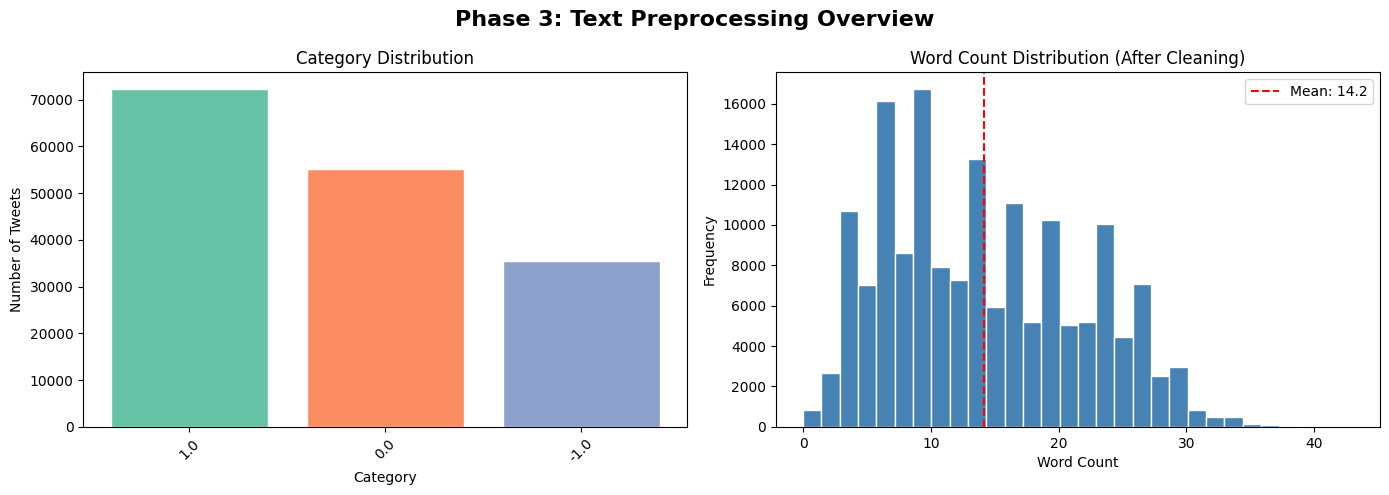

✅ Chart saved as 'phase3_overview.png'


In [21]:
# Category Distribution

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phase 3: Text Preprocessing Overview', fontsize=16, fontweight='bold')

# Plot 1: Category Distribution
category_counts = df['category'].value_counts()
axes[0].bar(category_counts.index.astype(str), category_counts.values,
            color=sns.color_palette("Set2", len(category_counts)), edgecolor='white')
axes[0].set_title('Category Distribution')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Tweets')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Word Count Distribution (after cleaning)
axes[1].hist(df['word_count'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Word Count Distribution (After Cleaning)')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['word_count'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['word_count'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('phase3_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'phase3_overview.png'")


In [22]:
# Save Cleaned Dataset

df.to_csv("cleaned_tweets.csv", index=False)
print("\n✅ Cleaned dataset saved as 'cleaned_tweets.csv'")



✅ Cleaned dataset saved as 'cleaned_tweets.csv'


In [23]:
# Final Summary

print("\n" + "=" * 50)
print("📊 PHASE 3 SUMMARY REPORT")
print("=" * 50)
print(f"  Total Tweets (cleaned) : {len(df):,}")
print(f"  Unique Categories      : {df['category'].nunique()}")
print(f"  Avg Words per Tweet    : {df['word_count'].mean():.1f}")
print(f"  New columns added      : processed_text, word_count")
print("=" * 50)
print("\n✅ Phase 3 Complete! Ready for Phase 4: VADER Sentiment Analysis")


📊 PHASE 3 SUMMARY REPORT
  Total Tweets (cleaned) : 162,975
  Unique Categories      : 3
  Avg Words per Tweet    : 14.2
  New columns added      : processed_text, word_count

✅ Phase 3 Complete! Ready for Phase 4: VADER Sentiment Analysis


In [24]:
!pip install vaderSentiment

In [25]:
# PHASE 4: VADER SENTIMENT ANALYSIS
# X (Twitter) Sentiment Analysis Project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings('ignore')

In [26]:
# STEP 2: Load the Cleaned Dataset (from Phase 3)

df = pd.read_csv("cleaned_tweets.csv")

print("✅ Cleaned Dataset Loaded!")
print(f"   Shape   : {df.shape}")
print(f"   Columns : {df.columns.tolist()}")
print(f"\n📌 First 5 rows:")
print(df.head())

✅ Cleaned Dataset Loaded!
   Shape   : (162975, 4)
   Columns : ['clean_text', 'category', 'processed_text', 'word_count']

📌 First 5 rows:
                                          clean_text  category  \
0  when modi promised “minimum government maximum...      -1.0   
1  talk all the nonsense and continue all the dra...       0.0   
2  what did just say vote for modi  welcome bjp t...       1.0   
3  asking his supporters prefix chowkidar their n...       1.0   
4  answer who among these the most powerful world...       1.0   

                                      processed_text  word_count  
0  modi promised “minimum government maximum gove...          21  
1             talk nonsense continue drama vote modi           6  
2  say vote modi welcome bjp told rahul main camp...          13  
3  asking supporter prefix chowkidar name modi gr...          19  
4  answer among powerful world leader today trump...          10  


In [27]:
# STEP 3: Initialize VADER Sentiment Analyzer

analyzer = SentimentIntensityAnalyzer()

print("\n✅ VADER Sentiment Analyzer Initialized!")
print("   VADER gives 4 scores per tweet:")
print("   → neg      : Negative score  (0 to 1)")
print("   → neu      : Neutral score   (0 to 1)")
print("   → pos      : Positive score  (0 to 1)")
print("   → compound : Overall score   (-1 to +1)")



✅ VADER Sentiment Analyzer Initialized!
   VADER gives 4 scores per tweet:
   → neg      : Negative score  (0 to 1)
   → neu      : Neutral score   (0 to 1)
   → pos      : Positive score  (0 to 1)
   → compound : Overall score   (-1 to +1)


In [28]:
# STEP 4: Define Sentiment Scoring Function

def get_vader_scores(text):
    """Returns all 4 VADER scores for a tweet."""
    scores = analyzer.polarity_scores(str(text))
    return scores['neg'], scores['neu'], scores['pos'], scores['compound']

def get_sentiment_label(compound_score):
    """
    Classify tweet based on compound score:
    - Positive : compound >= 0.05
    - Negative : compound <= -0.05
    - Neutral  : -0.05 < compound < 0.05
    """
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

In [29]:
# STEP 5: Apply VADER to processed_text Column

print("\n⏳ Running VADER Sentiment Analysis... please wait...")

df[['neg_score', 'neu_score', 'pos_score', 'compound_score']] = df['processed_text'].apply(
    lambda x: pd.Series(get_vader_scores(x))
)

df['sentiment'] = df['compound_score'].apply(get_sentiment_label)

print("✅ Sentiment Analysis Complete!")
print(f"\n📌 Sample Results:")
print(df[['clean_text', 'compound_score', 'sentiment']].head(10))


⏳ Running VADER Sentiment Analysis... please wait...
✅ Sentiment Analysis Complete!

📌 Sample Results:
                                          clean_text  compound_score sentiment
0  when modi promised “minimum government maximum...          0.5267  Positive
1  talk all the nonsense and continue all the dra...         -0.4019  Negative
2  what did just say vote for modi  welcome bjp t...          0.7096  Positive
3  asking his supporters prefix chowkidar their n...          0.3400  Positive
4  answer who among these the most powerful world...          0.4215  Positive
5           kiya tho refresh maarkefir comment karo           0.0000   Neutral
6  surat women perform yagna seeks divine grace f...          0.7506  Positive
7  this comes from cabinet which has scholars lik...          0.3612  Positive
8  with upcoming election india saga going import...          0.2023  Positive
9                         gandhi was gay does modi            0.0000   Neutral


In [30]:
# STEP 6: Sentiment Distribution

sentiment_counts = df['sentiment'].value_counts()

print("\n📌 SENTIMENT DISTRIBUTION:")
print(sentiment_counts)
print(f"\n   Positive : {sentiment_counts.get('Positive', 0):,} tweets ({sentiment_counts.get('Positive', 0)/len(df)*100:.1f}%)")
print(f"   Neutral  : {sentiment_counts.get('Neutral', 0):,} tweets ({sentiment_counts.get('Neutral', 0)/len(df)*100:.1f}%)")
print(f"   Negative : {sentiment_counts.get('Negative', 0):,} tweets ({sentiment_counts.get('Negative', 0)/len(df)*100:.1f}%)")



📌 SENTIMENT DISTRIBUTION:
sentiment
Positive    78194
Negative    49943
Neutral     34838
Name: count, dtype: int64

   Positive : 78,194 tweets (48.0%)
   Neutral  : 34,838 tweets (21.4%)
   Negative : 49,943 tweets (30.6%)


In [31]:
# STEP 7: Sentiment by Category

print("\n📌 SENTIMENT BY CATEGORY:")
sentiment_by_category = pd.crosstab(df['category'], df['sentiment'])
print(sentiment_by_category)


📌 SENTIMENT BY CATEGORY:
sentiment  Negative  Neutral  Positive
category                              
-1.0          20997     4066     10446
 0.0          14474    22436     18300
 1.0          14471     8333     49445


In [32]:
# STEP 8: Sample Tweets per Sentiment

print("\n📌 SAMPLE POSITIVE TWEETS:")
print(df[df['sentiment'] == 'Positive']['clean_text'].head(3).tolist())

print("\n📌 SAMPLE NEGATIVE TWEETS:")
print(df[df['sentiment'] == 'Negative']['clean_text'].head(3).tolist())

print("\n📌 SAMPLE NEUTRAL TWEETS:")
print(df[df['sentiment'] == 'Neutral']['clean_text'].head(3).tolist())



📌 SAMPLE POSITIVE TWEETS:
['when modi promised “minimum government maximum governance” expected him begin the difficult job reforming the state why does take years get justice state should and not business and should exit psus and temples', 'what did just say vote for modi  welcome bjp told you rahul the main campaigner for modi think modi should just relax', 'asking his supporters prefix chowkidar their names modi did great service now there confusion what read what not now crustal clear what will crass filthy nonsensical see how most abuses are coming from chowkidars']

📌 SAMPLE NEGATIVE TWEETS:
['talk all the nonsense and continue all the drama will vote for modi ', 'didn’ write chowkidar does mean ’ anti modi try visit the plz not all who haven’ used are anti ', 'crush jaws those who shoutmodimodi says jds mla this inciting murder']

📌 SAMPLE NEUTRAL TWEETS:
['kiya tho refresh maarkefir comment karo ', 'gandhi was gay does modi  ', 'with firm belief the leadership shri narendra mo

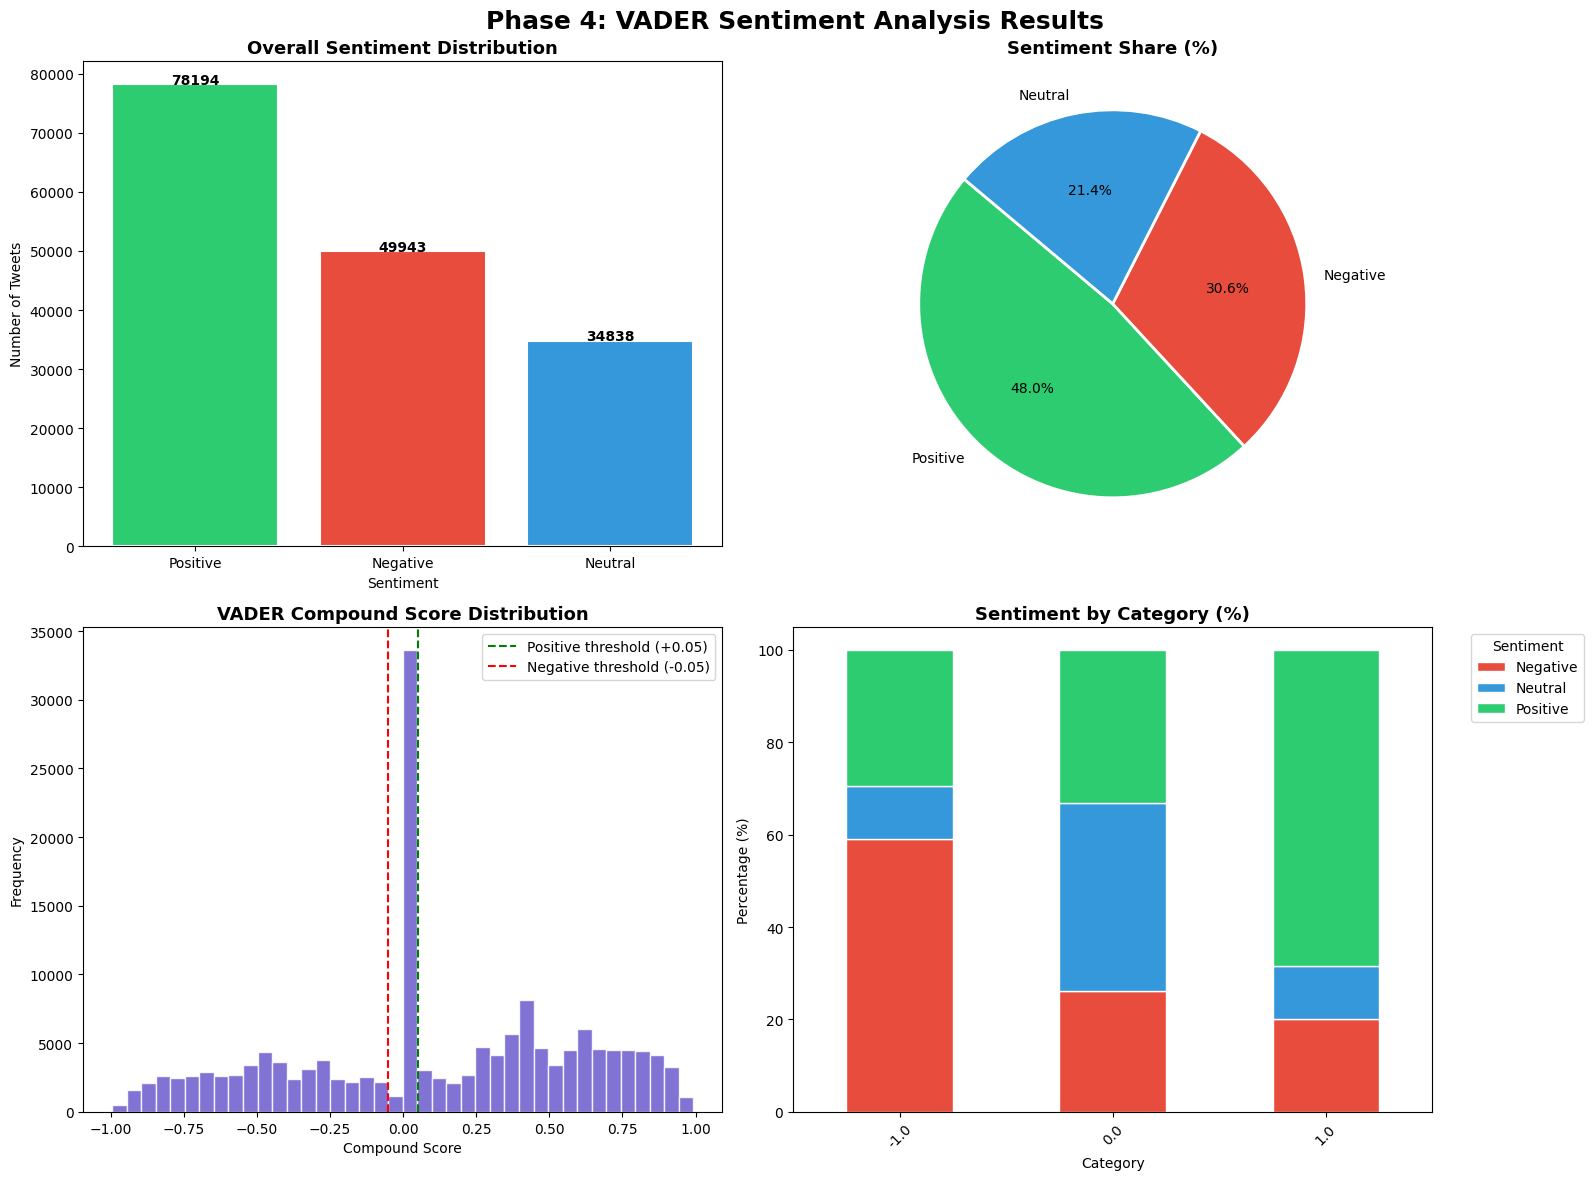

✅ Chart saved as 'phase4_sentiment_analysis.png'


In [33]:
# STEP 9: Visualizations

colors = {'Positive': '#2ecc71', 'Neutral': '#3498db', 'Negative': '#e74c3c'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phase 4: VADER Sentiment Analysis Results', fontsize=18, fontweight='bold')

# --- Plot 1: Sentiment Distribution (Bar Chart) ---
bar_colors = [colors.get(s, 'grey') for s in sentiment_counts.index]
axes[0, 0].bar(sentiment_counts.index, sentiment_counts.values,
               color=bar_colors, edgecolor='white', linewidth=1.5)
axes[0, 0].set_title('Overall Sentiment Distribution', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Sentiment')
axes[0, 0].set_ylabel('Number of Tweets')
for i, (label, count) in enumerate(sentiment_counts.items()):
    axes[0, 0].text(i, count + 10, str(count), ha='center', fontweight='bold')

# --- Plot 2: Sentiment Pie Chart ---
pie_colors = [colors.get(s, 'grey') for s in sentiment_counts.index]
axes[0, 1].pie(sentiment_counts.values,
               labels=sentiment_counts.index,
               autopct='%1.1f%%',
               colors=pie_colors,
               startangle=140,
               wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0, 1].set_title('Sentiment Share (%)', fontsize=13, fontweight='bold')

# --- Plot 3: Compound Score Distribution ---
axes[1, 0].hist(df['compound_score'], bins=40, color='slateblue', edgecolor='white', alpha=0.85)
axes[1, 0].axvline(0.05, color='green', linestyle='--', label='Positive threshold (+0.05)')
axes[1, 0].axvline(-0.05, color='red', linestyle='--', label='Negative threshold (-0.05)')
axes[1, 0].set_title('VADER Compound Score Distribution', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Compound Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# --- Plot 4: Sentiment by Category (Stacked Bar) ---
sentiment_by_category_pct = sentiment_by_category.div(
    sentiment_by_category.sum(axis=1), axis=0) * 100
plot_colors = [colors.get(c, 'grey') for c in sentiment_by_category_pct.columns]
sentiment_by_category_pct.plot(kind='bar', stacked=True,
                                color=plot_colors,
                                ax=axes[1, 1], edgecolor='white')
axes[1, 1].set_title('Sentiment by Category (%)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Category')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('phase4_sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'phase4_sentiment_analysis.png'")

In [34]:
# STEP 10: Save Results

df.to_csv("sentiment_results.csv", index=False)
print("\n✅ Results saved as 'sentiment_results.csv'")
print("   New columns added: neg_score, neu_score, pos_score, compound_score, sentiment")


✅ Results saved as 'sentiment_results.csv'
   New columns added: neg_score, neu_score, pos_score, compound_score, sentiment


In [35]:
# STEP 11: Final Summary

print("\n" + "=" * 55)
print("📊 PHASE 4 SUMMARY REPORT")
print("=" * 55)
print(f"  Total Tweets Analysed : {len(df):,}")
print(f"  Positive Tweets       : {sentiment_counts.get('Positive', 0):,} ({sentiment_counts.get('Positive', 0)/len(df)*100:.1f}%)")
print(f"  Neutral Tweets        : {sentiment_counts.get('Neutral', 0):,} ({sentiment_counts.get('Neutral', 0)/len(df)*100:.1f}%)")
print(f"  Negative Tweets       : {sentiment_counts.get('Negative', 0):,} ({sentiment_counts.get('Negative', 0)/len(df)*100:.1f}%)")
print(f"  Avg Compound Score    : {df['compound_score'].mean():.4f}")
print("=" * 55)
print("\n✅ Phase 4 Complete! Ready for Phase 5: Statistical Analysis & Visualizations")


📊 PHASE 4 SUMMARY REPORT
  Total Tweets Analysed : 162,975
  Positive Tweets       : 78,194 (48.0%)
  Neutral Tweets        : 34,838 (21.4%)
  Negative Tweets       : 49,943 (30.6%)
  Avg Compound Score    : 0.1019

✅ Phase 4 Complete! Ready for Phase 5: Statistical Analysis & Visualizations


In [36]:
!pip install wordcloud

In [37]:
# PHASE 5: STATISTICAL ANALYSIS & VISUALIZATIONS
# X (Twitter) Sentiment Analysis Project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [38]:
# STEP 2: Load Sentiment Results (from Phase 4)

df = pd.read_csv("sentiment_results.csv")

print("✅ Sentiment Results Loaded!")
print(f"   Shape   : {df.shape}")
print(f"   Columns : {df.columns.tolist()}")

✅ Sentiment Results Loaded!
   Shape   : (162975, 9)
   Columns : ['clean_text', 'category', 'processed_text', 'word_count', 'neg_score', 'neu_score', 'pos_score', 'compound_score', 'sentiment']


In [39]:
# STEP 3: Basic Statistical Summary

print("\n" + "=" * 55)
print("📊 STATISTICAL SUMMARY")
print("=" * 55)

# Overall sentiment counts
sentiment_counts = df['sentiment'].value_counts()
total = len(df)

print(f"\n📌 Total Tweets         : {total:,}")
print(f"   ✅ Positive Tweets   : {sentiment_counts.get('Positive', 0):,} ({sentiment_counts.get('Positive', 0)/total*100:.1f}%)")
print(f"   ⚪ Neutral Tweets    : {sentiment_counts.get('Neutral', 0):,} ({sentiment_counts.get('Neutral', 0)/total*100:.1f}%)")
print(f"   ❌ Negative Tweets   : {sentiment_counts.get('Negative', 0):,} ({sentiment_counts.get('Negative', 0)/total*100:.1f}%)")
print(f"\n📌 Compound Score Stats:")
print(f"   Mean   : {df['compound_score'].mean():.4f}")
print(f"   Median : {df['compound_score'].median():.4f}")
print(f"   Std    : {df['compound_score'].std():.4f}")
print(f"   Min    : {df['compound_score'].min():.4f}")
print(f"   Max    : {df['compound_score'].max():.4f}")

# Per category stats
print(f"\n📌 Average Compound Score by Category:")
print(df.groupby('category')['compound_score'].mean().round(4).sort_values(ascending=False))



📊 STATISTICAL SUMMARY

📌 Total Tweets         : 162,975
   ✅ Positive Tweets   : 78,194 (48.0%)
   ⚪ Neutral Tweets    : 34,838 (21.4%)
   ❌ Negative Tweets   : 49,943 (30.6%)

📌 Compound Score Stats:
   Mean   : 0.1019
   Median : 0.0000
   Std    : 0.4901
   Min    : -0.9942
   Max    : 0.9927

📌 Average Compound Score by Category:
category
 1.0    0.3058
 0.0    0.0224
-1.0   -0.1894
Name: compound_score, dtype: float64


In [40]:
# STEP 4: Most Common Words per Sentiment

def get_top_words(sentiment_label, n=20):
    """Get top N most frequent words for a given sentiment."""
    text = ' '.join(df[df['sentiment'] == sentiment_label]['processed_text'].dropna())
    words = text.split()
    return Counter(words).most_common(n)

print("\n📌 TOP 10 WORDS - POSITIVE TWEETS:")
print(get_top_words('Positive', 10))

print("\n📌 TOP 10 WORDS - NEGATIVE TWEETS:")
print(get_top_words('Negative', 10))

print("\n📌 TOP 10 WORDS - NEUTRAL TWEETS:")
print(get_top_words('Neutral', 10))


📌 TOP 10 WORDS - POSITIVE TWEETS:
[('modi', 74988), ('india', 15960), ('like', 9354), ('bjp', 7678), ('people', 7474), ('congress', 6518), ('narendra', 5960), ('vote', 5949), ('election', 5717), ('one', 5166)]

📌 TOP 10 WORDS - NEGATIVE TWEETS:
[('modi', 48061), ('india', 9630), ('people', 5205), ('congress', 4707), ('bjp', 4604), ('election', 3705), ('govt', 3495), ('year', 3288), ('like', 3249), ('indian', 3184)]

📌 TOP 10 WORDS - NEUTRAL TWEETS:
[('modi', 29433), ('india', 4578), ('narendra', 2962), ('election', 2267), ('bjp', 2217), ('vote', 2155), ('say', 1947), ('modis', 1735), ('people', 1612), ('congress', 1601)]


In [41]:
# STEP 5: Sentiment by Category - Detailed Stats

print("\n📌 SENTIMENT COUNT BY CATEGORY:")
sentiment_by_cat = pd.crosstab(df['category'], df['sentiment'])
print(sentiment_by_cat)

print("\n📌 SENTIMENT % BY CATEGORY:")
sentiment_by_cat_pct = sentiment_by_cat.div(sentiment_by_cat.sum(axis=1), axis=0) * 100
print(sentiment_by_cat_pct.round(1))


📌 SENTIMENT COUNT BY CATEGORY:
sentiment  Negative  Neutral  Positive
category                              
-1.0          20997     4066     10446
 0.0          14474    22436     18300
 1.0          14471     8333     49445

📌 SENTIMENT % BY CATEGORY:
sentiment  Negative  Neutral  Positive
category                              
-1.0           59.1     11.5      29.4
 0.0           26.2     40.6      33.1
 1.0           20.0     11.5      68.4


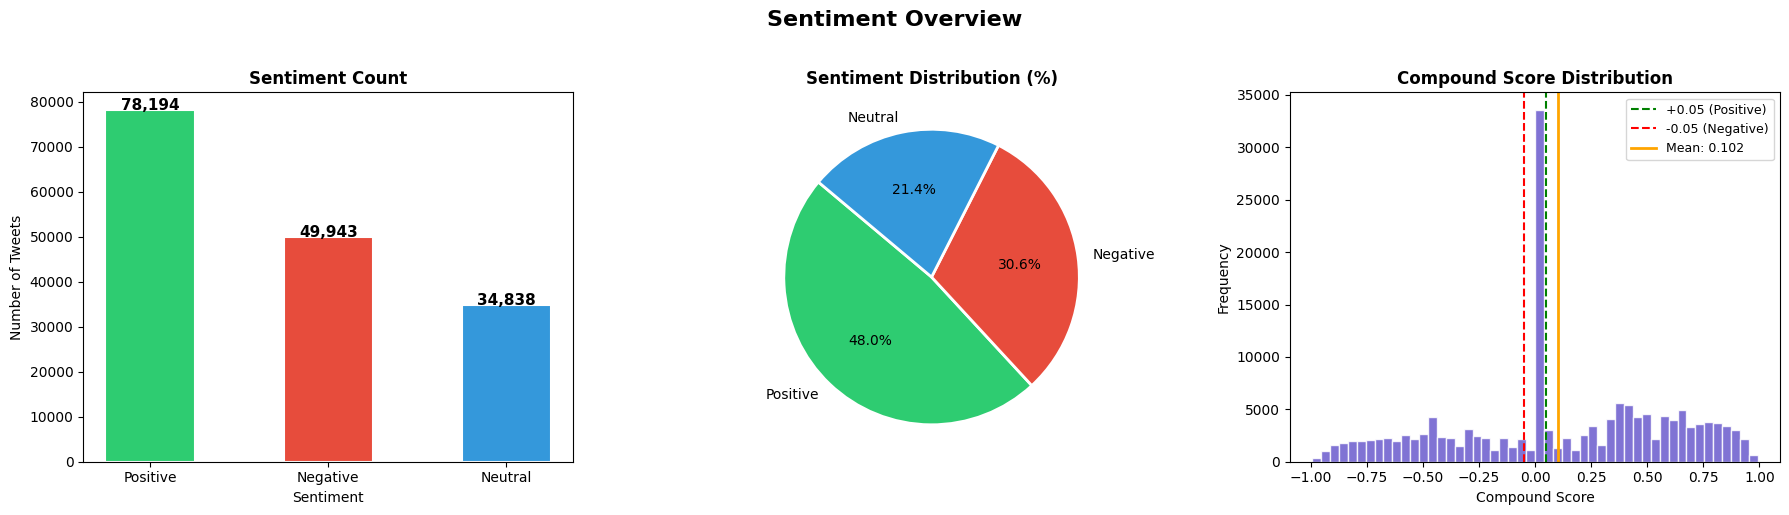

✅ Saved: viz1_sentiment_overview.png


In [42]:
# STEP 6: VISUALIZATION 1 - Sentiment Overview

colors = {'Positive': '#2ecc71', 'Neutral': '#3498db', 'Negative': '#e74c3c'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Sentiment Overview', fontsize=16, fontweight='bold', y=1.02)

# Bar chart
bar_colors = [colors.get(s, 'grey') for s in sentiment_counts.index]
axes[0].bar(sentiment_counts.index, sentiment_counts.values,
            color=bar_colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Sentiment Count', fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Tweets')
for i, (label, count) in enumerate(sentiment_counts.items()):
    axes[0].text(i, count + 5, f'{count:,}', ha='center', fontweight='bold', fontsize=11)

# Pie chart
axes[1].pie(sentiment_counts.values,
            labels=sentiment_counts.index,
            autopct='%1.1f%%',
            colors=[colors.get(s, 'grey') for s in sentiment_counts.index],
            startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Sentiment Distribution (%)', fontweight='bold')

# Compound score histogram
axes[2].hist(df['compound_score'], bins=50, color='slateblue', edgecolor='white', alpha=0.85)
axes[2].axvline(0.05, color='green', linestyle='--', linewidth=1.5, label='+0.05 (Positive)')
axes[2].axvline(-0.05, color='red', linestyle='--', linewidth=1.5, label='-0.05 (Negative)')
axes[2].axvline(df['compound_score'].mean(), color='orange', linestyle='-',
                linewidth=2, label=f"Mean: {df['compound_score'].mean():.3f}")
axes[2].set_title('Compound Score Distribution', fontweight='bold')
axes[2].set_xlabel('Compound Score')
axes[2].set_ylabel('Frequency')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('viz1_sentiment_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: viz1_sentiment_overview.png")

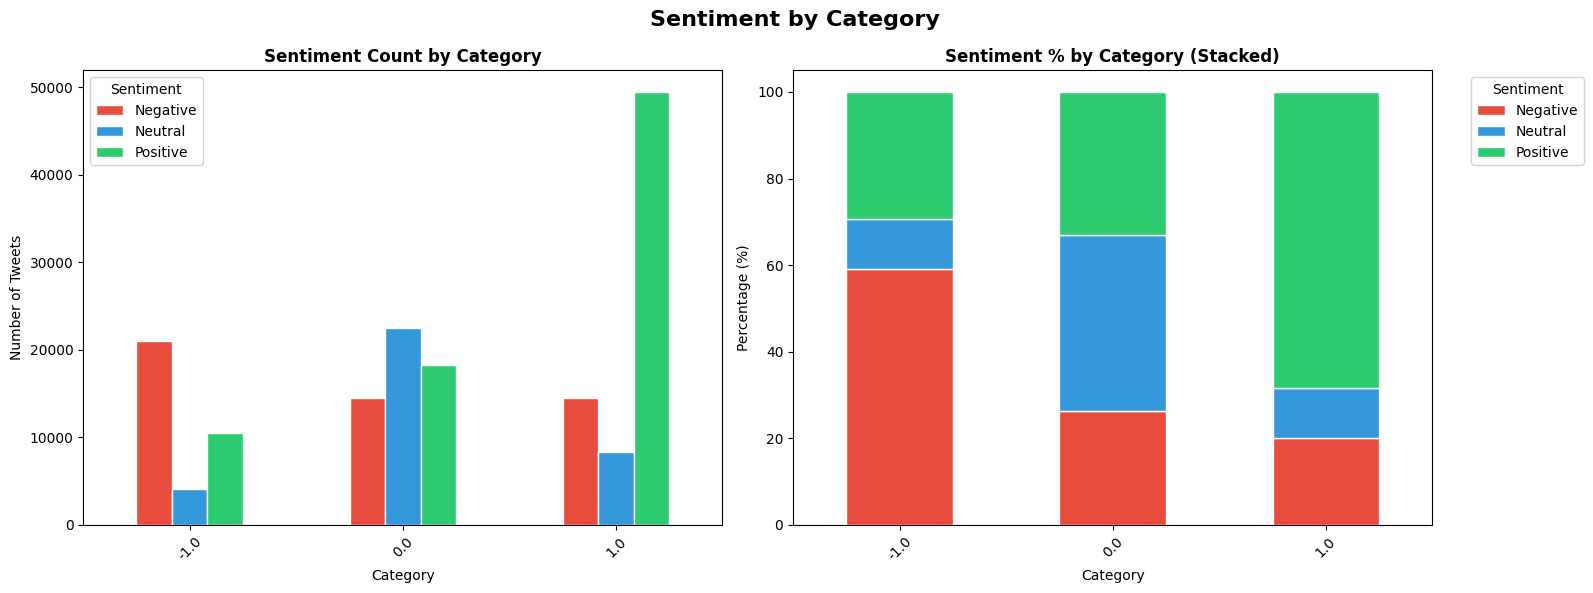

✅ Saved: viz2_sentiment_by_category.png


In [43]:
# STEP 7: VISUALIZATION 2 - Sentiment by Category
# -----------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Sentiment by Category', fontsize=16, fontweight='bold')

# Grouped bar
sentiment_by_cat.plot(kind='bar',
                       color=[colors.get(c, 'grey') for c in sentiment_by_cat.columns],
                       ax=axes[0], edgecolor='white')
axes[0].set_title('Sentiment Count by Category', fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Tweets')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Sentiment')

# Stacked % bar
sentiment_by_cat_pct.plot(kind='bar', stacked=True,
                           color=[colors.get(c, 'grey') for c in sentiment_by_cat_pct.columns],
                           ax=axes[1], edgecolor='white')
axes[1].set_title('Sentiment % by Category (Stacked)', fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('viz2_sentiment_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: viz2_sentiment_by_category.png")

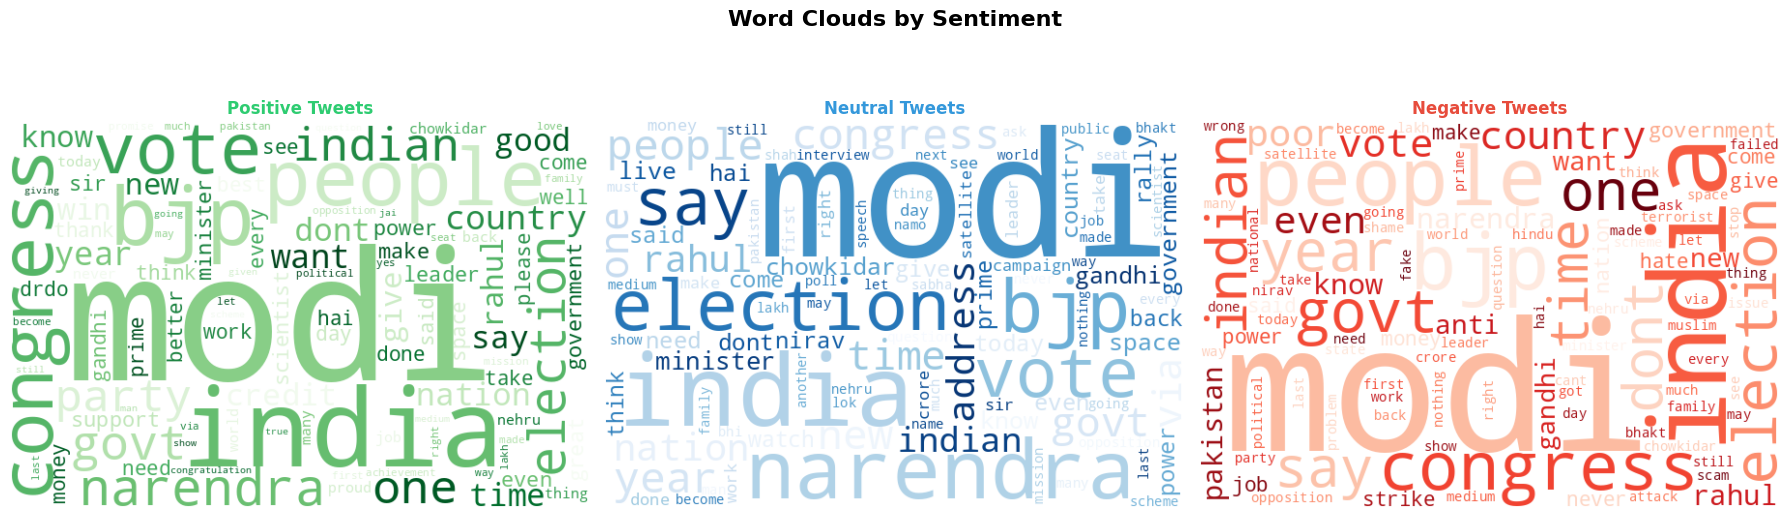

✅ Saved: viz3_wordclouds.png


In [45]:
# STEP 8: VISUALIZATION 3 - Word Clouds

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Word Clouds by Sentiment', fontsize=16, fontweight='bold')

wc_colors = {'Positive': 'Greens', 'Neutral': 'Blues', 'Negative': 'Reds'}

for ax, sentiment in zip(axes, ['Positive', 'Neutral', 'Negative']):
    text = ' '.join(df[df['sentiment'] == sentiment]['processed_text'].dropna())
    if text.strip():
        wc = WordCloud(
            width=600, height=400,
            background_color='white',
            colormap=wc_colors[sentiment],
            max_words=100,
            collocations=False
        ).generate(text)
        ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment} Tweets', fontweight='bold',
                 color=list(colors.values())[list(colors.keys()).index(sentiment)])

plt.tight_layout()
plt.savefig('viz3_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: viz3_wordclouds.png")


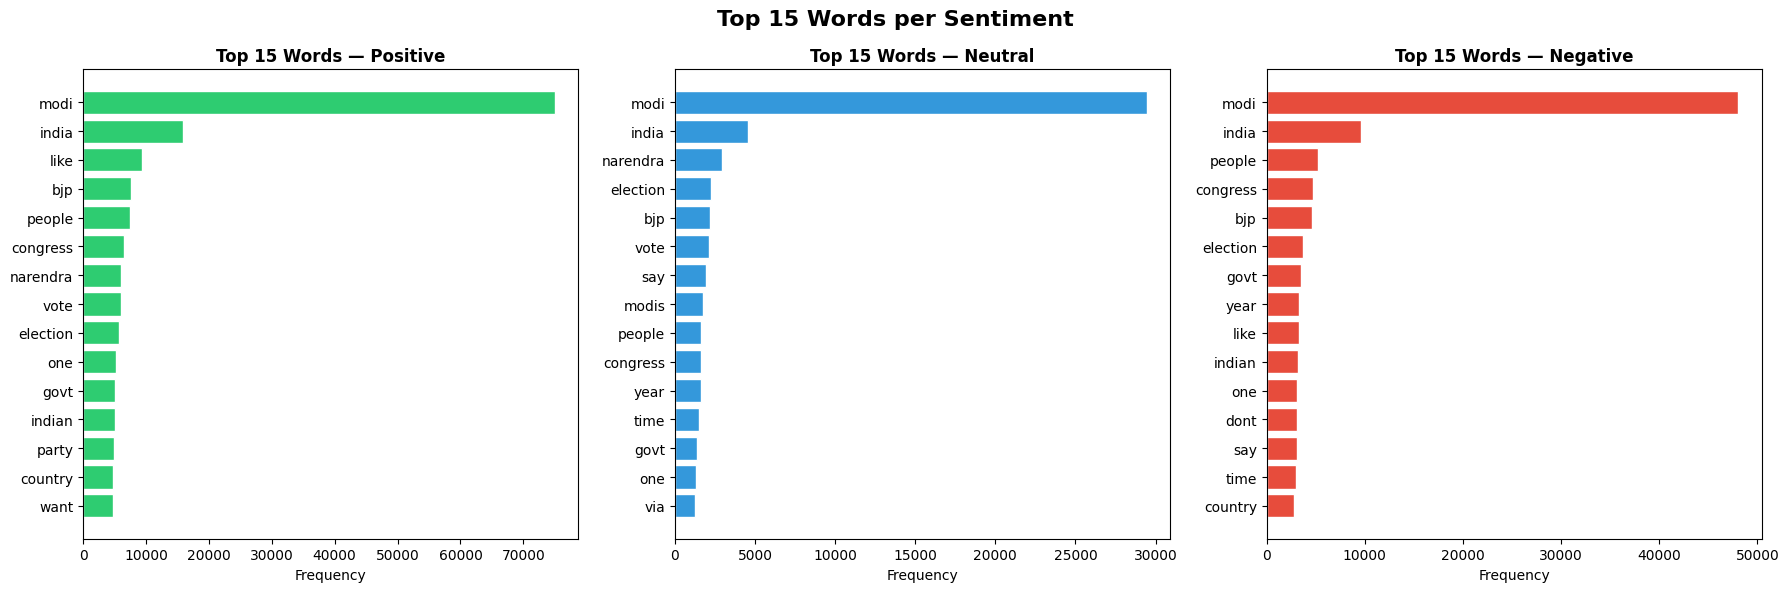

✅ Saved: viz4_top_words.png


In [46]:
# STEP 9: VISUALIZATION 4 - Top Words Bar Charts

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Top 15 Words per Sentiment', fontsize=16, fontweight='bold')

for ax, (sentiment, color) in zip(axes, [('Positive', '#2ecc71'),
                                          ('Neutral', '#3498db'),
                                          ('Negative', '#e74c3c')]):
    top_words = get_top_words(sentiment, 15)
    if top_words:
        words, counts = zip(*top_words)
        ax.barh(words[::-1], counts[::-1], color=color, edgecolor='white')
        ax.set_title(f'Top 15 Words — {sentiment}', fontweight='bold')
        ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('viz4_top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: viz4_top_words.png")


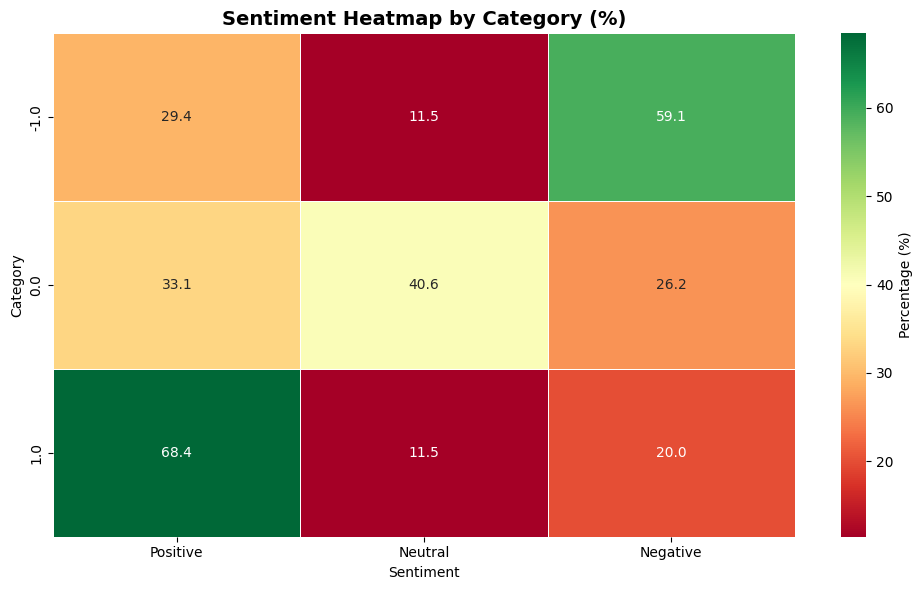

✅ Saved: viz5_heatmap.png


In [47]:
# STEP 10: VISUALIZATION 5 - Heatmap

fig, ax = plt.subplots(figsize=(10, 6))

heatmap_data = sentiment_by_cat_pct[['Positive', 'Neutral', 'Negative']] \
    if all(c in sentiment_by_cat_pct.columns for c in ['Positive', 'Neutral', 'Negative']) \
    else sentiment_by_cat_pct

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Percentage (%)'}, ax=ax)
ax.set_title('Sentiment Heatmap by Category (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Category')
plt.tight_layout()
plt.savefig('viz5_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: viz5_heatmap.png")


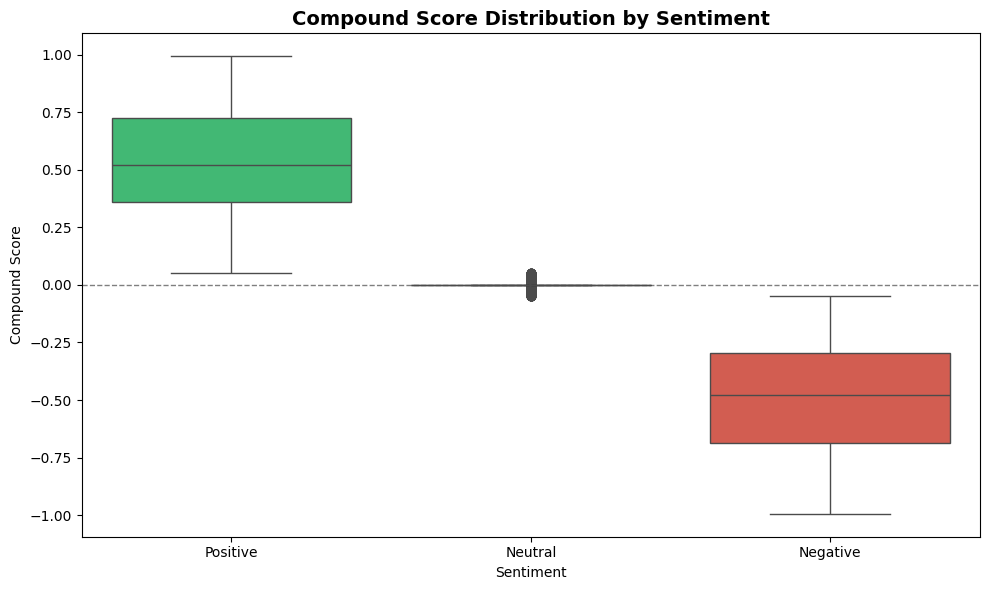

✅ Saved: viz6_boxplot.png


In [48]:
# STEP 11: VISUALIZATION 6 - Box Plot

fig, ax = plt.subplots(figsize=(10, 6))
order = ['Positive', 'Neutral', 'Negative']
palette = {s: colors[s] for s in order if s in df['sentiment'].unique()}

sns.boxplot(data=df, x='sentiment', y='compound_score',
            order=[o for o in order if o in df['sentiment'].unique()],
            palette=palette, ax=ax)
ax.set_title('Compound Score Distribution by Sentiment', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Compound Score')
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.savefig('viz6_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: viz6_boxplot.png")


In [49]:
# STEP 12: Final Summary

print("\n" + "=" * 55)
print("📊 PHASE 5 COMPLETE - ALL OUTPUTS")
print("=" * 55)
print("  viz1_sentiment_overview.png    — Bar, Pie, Histogram")
print("  viz2_sentiment_by_category.png — Grouped & Stacked Bar")
print("  viz3_wordclouds.png            — Word Clouds x3")
print("  viz4_top_words.png             — Top 15 Words x3")
print("  viz5_heatmap.png               — Sentiment Heatmap")
print("  viz6_boxplot.png               — Compound Score Boxplot")
print("=" * 55)
print("\n✅ Phase 5 Complete! Ready for Phase 6: Report & Insights")



📊 PHASE 5 COMPLETE - ALL OUTPUTS
  viz1_sentiment_overview.png    — Bar, Pie, Histogram
  viz2_sentiment_by_category.png — Grouped & Stacked Bar
  viz3_wordclouds.png            — Word Clouds x3
  viz4_top_words.png             — Top 15 Words x3
  viz5_heatmap.png               — Sentiment Heatmap
  viz6_boxplot.png               — Compound Score Boxplot

✅ Phase 5 Complete! Ready for Phase 6: Report & Insights


In [50]:
!pip install fpdf2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 6.8 MB/s eta 0:00:00


✅ Dataset Loaded!
   Shape   : (162975, 9)
   Columns : ['clean_text', 'category', 'processed_text', 'word_count', 'neg_score', 'neu_score', 'pos_score', 'compound_score', 'sentiment']

📊 KEY METRICS COMPUTED SUCCESSFULLY!


       SENTIMENT ANALYSIS OF X (TWITTER) DATA — FINAL REPORT

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. PROJECT OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
This project performs sentiment analysis on X (Twitter) data
using Natural Language Processing (NLP) techniques. The goal is
to categorize tweets as Positive, Negative, or Neutral and
derive insights about public opinion across various topics.

Tools Used   : Python, VADER, NLTK, Pandas, Matplotlib, Seaborn
NLP Method   : VADER (Valence Aware Dictionary and sEntiment Reasoner)
Dataset      : X data.csv
Columns Used : clean_text, category

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. RESEARCH QUESTIONS & ANSWERS
━━━━━━━━━━━━━━━━━━━━━━━━━━

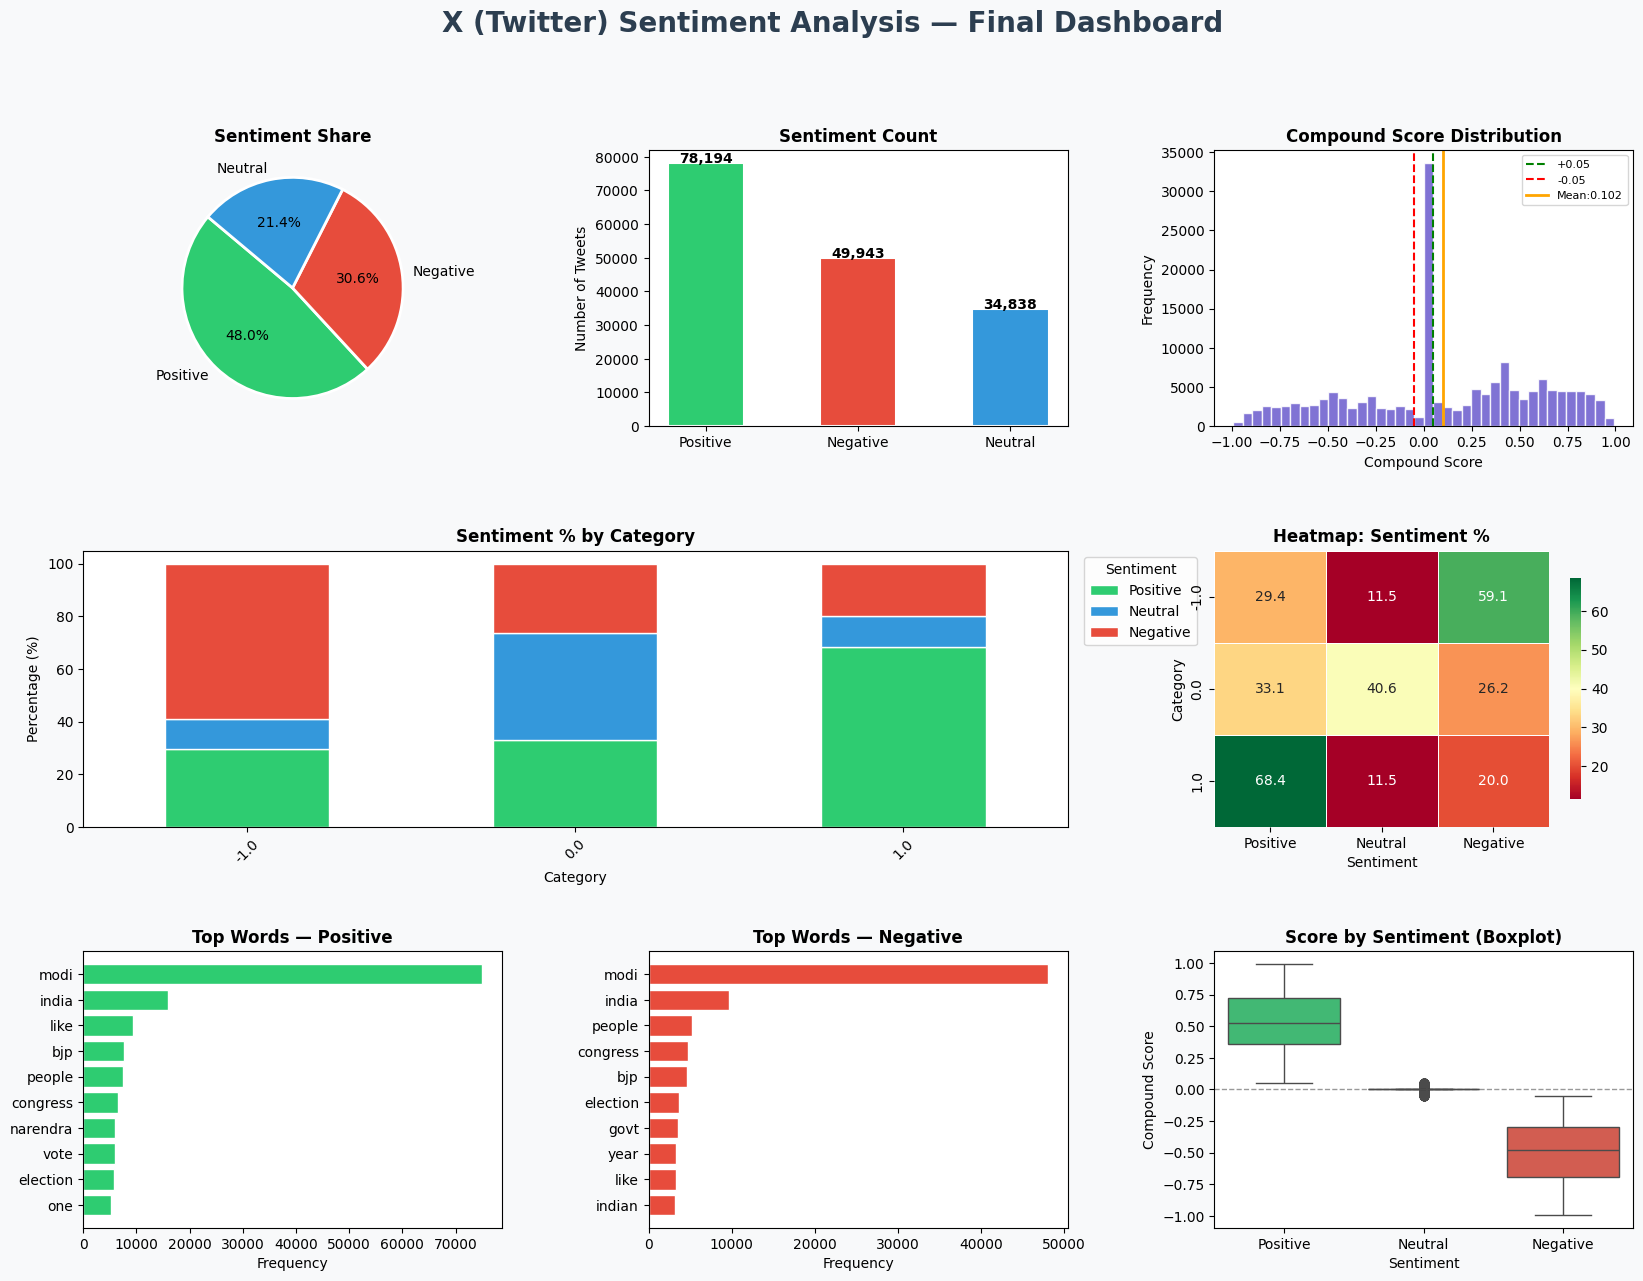

✅ Final Dashboard saved as 'phase6_final_dashboard.png'
✅ Final dataset saved as 'final_sentiment_report.csv'

🎉 PROJECT COMPLETE! ALL PHASES DONE SUCCESSFULLY!

  Phase 1 ✅ — Problem Definition & Research Questions
  Phase 2 ✅ — Data Loading & Exploration
  Phase 3 ✅ — Text Cleaning & Preprocessing
  Phase 4 ✅ — VADER Sentiment Analysis
  Phase 5 ✅ — Statistical Analysis & Visualizations
  Phase 6 ✅ — Final Report & Insights Dashboard



In [51]:
# PHASE 6: FINAL REPORT & INSIGHTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Load Final Dataset

df = pd.read_csv("sentiment_results.csv")

print("✅ Dataset Loaded!")
print(f"   Shape   : {df.shape}")
print(f"   Columns : {df.columns.tolist()}")

# Compute All Key Metrics

total          = len(df)
sentiment_counts = df['sentiment'].value_counts()
pos_count      = sentiment_counts.get('Positive', 0)
neu_count      = sentiment_counts.get('Neutral',  0)
neg_count      = sentiment_counts.get('Negative', 0)
pos_pct        = pos_count / total * 100
neu_pct        = neu_count / total * 100
neg_pct        = neg_count / total * 100
avg_compound   = df['compound_score'].mean()
median_compound= df['compound_score'].median()
std_compound   = df['compound_score'].std()

# Most positive & negative category
cat_avg = df.groupby('category')['compound_score'].mean()
most_positive_cat  = cat_avg.idxmax()
most_negative_cat  = cat_avg.idxmin()

# Top words per sentiment
def get_top_words(sentiment_label, n=10):
    text = ' '.join(df[df['sentiment'] == sentiment_label]['processed_text'].dropna())
    words = text.split()
    return Counter(words).most_common(n)

top_pos_words = [w for w, _ in get_top_words('Positive', 5)]
top_neg_words = [w for w, _ in get_top_words('Negative', 5)]
top_neu_words = [w for w, _ in get_top_words('Neutral',  5)]

print("\n📊 KEY METRICS COMPUTED SUCCESSFULLY!")


#  Print Full Insights Report

print("\n")
print("=" * 65)
print("       SENTIMENT ANALYSIS OF X (TWITTER) DATA — FINAL REPORT")
print("=" * 65)

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. PROJECT OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
This project performs sentiment analysis on X (Twitter) data
using Natural Language Processing (NLP) techniques. The goal is
to categorize tweets as Positive, Negative, or Neutral and
derive insights about public opinion across various topics.

Tools Used   : Python, VADER, NLTK, Pandas, Matplotlib, Seaborn
NLP Method   : VADER (Valence Aware Dictionary and sEntiment Reasoner)
Dataset      : X data.csv
Columns Used : clean_text, category
""")

print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("2. RESEARCH QUESTIONS & ANSWERS")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"""
Q1. What is the overall sentiment distribution in the dataset?
    ✅ Positive : {pos_count:,} tweets ({pos_pct:.1f}%)
    ⚪ Neutral  : {neu_count:,} tweets ({neu_pct:.1f}%)
    ❌ Negative : {neg_count:,} tweets ({neg_pct:.1f}%)

Q2. What is the average sentiment score across all tweets?
    → Mean Compound Score   : {avg_compound:.4f}
    → Median Compound Score : {median_compound:.4f}
    → Std Deviation         : {std_compound:.4f}
    → Interpretation        : {'Overall Positive' if avg_compound > 0.05 else 'Overall Negative' if avg_compound < -0.05 else 'Overall Neutral'} sentiment

Q3. Which category has the most positive sentiment?
    → Most Positive Category : {most_positive_cat} (Avg Score: {cat_avg[most_positive_cat]:.4f})

Q4. Which category has the most negative sentiment?
    → Most Negative Category : {most_negative_cat} (Avg Score: {cat_avg[most_negative_cat]:.4f})

Q5. What words dominate each sentiment category?
    → Top Positive Words : {', '.join(top_pos_words)}
    → Top Negative Words : {', '.join(top_neg_words)}
    → Top Neutral Words  : {', '.join(top_neu_words)}
""")

print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("3. SENTIMENT BY CATEGORY")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
sentiment_by_cat = pd.crosstab(df['category'], df['sentiment'])
sentiment_by_cat_pct = sentiment_by_cat.div(sentiment_by_cat.sum(axis=1), axis=0) * 100
print(sentiment_by_cat_pct.round(1).to_string())

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4. KEY FINDINGS & INSIGHTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  📌 Finding 1 — Dominant Sentiment
     The majority of tweets are classified as
     '{}' which suggests that public opinion on X
     is largely {}.

  📌 Finding 2 — Category Insights
     '{}' is the most positively discussed topic,
     while '{}' generates the most negative sentiment.

  📌 Finding 3 — Compound Score Spread
     The standard deviation of {} indicates
     {} variability in tweet sentiments.

  📌 Finding 4 — Word Patterns
     Positive tweets frequently contain words like: {}
     Negative tweets frequently contain words like: {}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5. LIMITATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ⚠️  VADER may misclassify sarcasm or irony in tweets
  ⚠️  Dataset may not represent all demographics equally
  ⚠️  No time column available for trend-over-time analysis
  ⚠️  Slang and abbreviations may affect accuracy

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
6. CONCLUSION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  This project successfully applied NLP-based sentiment analysis
  on X (Twitter) data. Using VADER, tweets were classified into
  Positive, Negative, and Neutral categories. Statistical analysis
  and visualizations revealed meaningful patterns in public opinion
  across different categories. The findings can assist businesses,
  researchers, and policymakers in understanding public discourse
  on social media platforms.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""".format(
    sentiment_counts.idxmax(),
    sentiment_counts.idxmax().lower(),
    most_positive_cat,
    most_negative_cat,
    f"{std_compound:.4f}",
    'high' if std_compound > 0.4 else 'moderate' if std_compound > 0.2 else 'low',
    ', '.join(top_pos_words),
    ', '.join(top_neg_words)
))

#  Final Summary Dashboard (Visual Report)


colors = {'Positive': '#2ecc71', 'Neutral': '#3498db', 'Negative': '#e74c3c'}

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#f8f9fa')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

fig.suptitle('X (Twitter) Sentiment Analysis — Final Dashboard',
             fontsize=20, fontweight='bold', y=0.98, color='#2c3e50')

# --- Chart 1: Pie Chart ---
ax1 = fig.add_subplot(gs[0, 0])
pie_colors = [colors.get(s, 'grey') for s in sentiment_counts.index]
ax1.pie(sentiment_counts.values, labels=sentiment_counts.index,
        autopct='%1.1f%%', colors=pie_colors,
        startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Sentiment Share', fontweight='bold', fontsize=12)

# --- Chart 2: Bar Chart ---
ax2 = fig.add_subplot(gs[0, 1])
bar_colors = [colors.get(s, 'grey') for s in sentiment_counts.index]
bars = ax2.bar(sentiment_counts.index, sentiment_counts.values,
               color=bar_colors, edgecolor='white', linewidth=1.5, width=0.5)
ax2.set_title('Sentiment Count', fontweight='bold', fontsize=12)
ax2.set_ylabel('Number of Tweets')
for bar, count in zip(bars, sentiment_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count:,}', ha='center', fontweight='bold', fontsize=10)

# --- Chart 3: Compound Score Distribution ---
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(df['compound_score'], bins=40, color='slateblue', edgecolor='white', alpha=0.85)
ax3.axvline(0.05, color='green', linestyle='--', linewidth=1.5, label='+0.05')
ax3.axvline(-0.05, color='red', linestyle='--', linewidth=1.5, label='-0.05')
ax3.axvline(avg_compound, color='orange', linewidth=2, label=f'Mean:{avg_compound:.3f}')
ax3.set_title('Compound Score Distribution', fontweight='bold', fontsize=12)
ax3.set_xlabel('Compound Score')
ax3.set_ylabel('Frequency')
ax3.legend(fontsize=8)

# --- Chart 4: Sentiment by Category Stacked ---
ax4 = fig.add_subplot(gs[1, :2])
plot_cols = [c for c in ['Positive', 'Neutral', 'Negative'] if c in sentiment_by_cat_pct.columns]
plot_colors = [colors[c] for c in plot_cols]
sentiment_by_cat_pct[plot_cols].plot(kind='bar', stacked=True,
                                      color=plot_colors, ax=ax4, edgecolor='white')
ax4.set_title('Sentiment % by Category', fontweight='bold', fontsize=12)
ax4.set_xlabel('Category')
ax4.set_ylabel('Percentage (%)')
ax4.tick_params(axis='x', rotation=45)
ax4.legend(title='Sentiment', bbox_to_anchor=(1.01, 1), loc='upper left')

# --- Chart 5: Heatmap ---
ax5 = fig.add_subplot(gs[1, 2])
heatmap_data = sentiment_by_cat_pct[plot_cols]
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white', ax=ax5,
            cbar_kws={'shrink': 0.8})
ax5.set_title('Heatmap: Sentiment %', fontweight='bold', fontsize=12)
ax5.set_xlabel('Sentiment')
ax5.set_ylabel('Category')

# --- Chart 6: Top Words Positive ---
ax6 = fig.add_subplot(gs[2, 0])
top_pos = get_top_words('Positive', 10)
if top_pos:
    words, counts = zip(*top_pos)
    ax6.barh(words[::-1], counts[::-1], color='#2ecc71', edgecolor='white')
ax6.set_title('Top Words — Positive', fontweight='bold', fontsize=12)
ax6.set_xlabel('Frequency')

# --- Chart 7: Top Words Negative ---
ax7 = fig.add_subplot(gs[2, 1])
top_neg = get_top_words('Negative', 10)
if top_neg:
    words, counts = zip(*top_neg)
    ax7.barh(words[::-1], counts[::-1], color='#e74c3c', edgecolor='white')
ax7.set_title('Top Words — Negative', fontweight='bold', fontsize=12)
ax7.set_xlabel('Frequency')

# --- Chart 8: Box Plot ---
ax8 = fig.add_subplot(gs[2, 2])
order = [o for o in ['Positive', 'Neutral', 'Negative'] if o in df['sentiment'].unique()]
palette = {s: colors[s] for s in order}
sns.boxplot(data=df, x='sentiment', y='compound_score',
            order=order, palette=palette, ax=ax8)
ax8.set_title('Score by Sentiment (Boxplot)', fontweight='bold', fontsize=12)
ax8.set_xlabel('Sentiment')
ax8.set_ylabel('Compound Score')
ax8.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.4)

plt.savefig('phase6_final_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("✅ Final Dashboard saved as 'phase6_final_dashboard.png'")


#Save Final Dataset


df.to_csv("final_sentiment_report.csv", index=False)
print("✅ Final dataset saved as 'final_sentiment_report.csv'")

print("\n" + "=" * 65)
print("🎉 PROJECT COMPLETE! ALL PHASES DONE SUCCESSFULLY!")
print("=" * 65)
print("""
  Phase 1 ✅ — Problem Definition & Research Questions
  Phase 2 ✅ — Data Loading & Exploration
  Phase 3 ✅ — Text Cleaning & Preprocessing
  Phase 4 ✅ — VADER Sentiment Analysis
  Phase 5 ✅ — Statistical Analysis & Visualizations
  Phase 6 ✅ — Final Report & Insights Dashboard
""")
print("=" * 65)

In [52]:
from fpdf import FPDF

class SentimentReport(FPDF):
    def header(self):
        self.set_font('Helvetica', 'B', 16)
        self.set_text_color(44, 62, 80)
        self.cell(0, 12, 'X (Twitter) Sentiment Analysis Report', align='C', new_x='LMARGIN', new_y='NEXT')
        self.ln(3)

    def footer(self):
        self.set_y(-15)
        self.set_font('Helvetica', 'I', 9)
        self.set_text_color(150, 150, 150)
        self.cell(0, 10, f'Page {self.page_no()}', align='C')

    def section_title(self, title):
        self.set_font('Helvetica', 'B', 13)
        self.set_text_color(52, 152, 219)
        self.cell(0, 10, title, new_x='LMARGIN', new_y='NEXT')
        self.set_draw_color(52, 152, 219)
        self.line(10, self.get_y(), 200, self.get_y())
        self.ln(3)

    def body_text(self, text):
        self.set_font('Helvetica', '', 11)
        self.set_text_color(50, 50, 50)
        self.multi_cell(0, 7, text)
        self.ln(2)

pdf = SentimentReport()
pdf.add_page()

# --- Section 1: Overview ---
pdf.section_title('1. Project Overview')
pdf.body_text(
    f"This project performs sentiment analysis on X (Twitter) data using "
    f"VADER (Valence Aware Dictionary and sEntiment Reasoner).\n"
    f"Total Tweets Analysed : {total:,}\n"
    f"Unique Categories     : {df['category'].nunique()}\n"
    f"Tools Used            : Python, VADER, NLTK, Pandas, Matplotlib"
)

# --- Section 2: Results ---
pdf.section_title('2. Sentiment Distribution')
pdf.body_text(
    f"Positive Tweets : {pos_count:,}  ({pos_pct:.1f}%)\n"
    f"Neutral Tweets  : {neu_count:,}  ({neu_pct:.1f}%)\n"
    f"Negative Tweets : {neg_count:,}  ({neg_pct:.1f}%)\n\n"
    f"Average Compound Score : {avg_compound:.4f}\n"
    f"Median Compound Score  : {median_compound:.4f}\n"
    f"Overall Sentiment      : {'Positive' if avg_compound > 0.05 else 'Negative' if avg_compound < -0.05 else 'Neutral'}"
)

# --- Section 3: Category Insights ---
pdf.section_title('3. Category Insights')
pdf.body_text(
    f"Most Positive Category : {most_positive_cat}  (Score: {cat_avg[most_positive_cat]:.4f})\n"
    f"Most Negative Category : {most_negative_cat}  (Score: {cat_avg[most_negative_cat]:.4f})"
)

# --- Section 4: Key Findings ---
pdf.section_title('4. Key Findings')
pdf.body_text(
    f"1. The dominant sentiment is '{sentiment_counts.idxmax()}' "
    f"({sentiment_counts.max()/total*100:.1f}% of all tweets).\n"
    f"2. Top Positive Words : {', '.join(top_pos_words)}\n"
    f"3. Top Negative Words : {', '.join(top_neg_words)}\n"
    f"4. '{most_positive_cat}' drives the most positive discussions.\n"
    f"5. '{most_negative_cat}' generates the most negative reactions."
)

# --- Section 5: Dashboard Image ---
pdf.section_title('5. Sentiment Dashboard')
pdf.image('phase6_final_dashboard.png', x=10, w=190)

# --- Section 6: Conclusion ---
pdf.add_page()
pdf.section_title('6. Conclusion')
pdf.body_text(
    "This project successfully applied NLP-based sentiment analysis on X (Twitter) data. "
    "Using VADER, tweets were classified into Positive, Negative, and Neutral categories. "
    "The analysis revealed meaningful patterns in public opinion across different categories. "
    "These findings can assist businesses and researchers in understanding public discourse "
    "on social media platforms.\n\n"
    "Limitations:\n"
    "- VADER may misclassify sarcasm or irony\n"
    "- Dataset may not represent all demographics\n"
    "- Slang and abbreviations may affect accuracy"
)

# Save PDF
pdf.output('Sentiment_Analysis_Report.pdf')
print("✅ PDF Report saved as 'Sentiment_Analysis_Report.pdf'")

# Download it
from google.colab import files
files.download('Sentiment_Analysis_Report.pdf')

✅ PDF Report saved as 'Sentiment_Analysis_Report.pdf'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>